This notebook has been inspired from [Tabular_SARSA](https://colab.research.google.com/github/probml/pyprobml/blob/master/notebooks/book2/35/supplementary/Tabular_SARSA.ipynb) by Amouzgar & Murphy and [SARSA Reinforcement Learning](https://www.geeksforgeeks.org/sarsa-reinforcement-learning/) by Alinda

# SARSA

**Assignment 1 — Section 2: SARSA on FrozenLake-v1**

Tasks completed: **T1, T2, T3**

In this notebook, we will implement SARSA Reinforcement learning

---

algorithm for Frozen Lake Environment.

## Frozen Lake

Frozen lake is a toy text environment involves crossing a frozen lake from start to goal without falling into any holes by walking over the frozen lake. <br>

We can also set the lake to be slippery so that the agent does not always move in the intended direction. \but here, we will only look at the non-slippery case. But you are welcome to try the slippery one.<br>

You can read more about the environment [here](https://gymnasium.farama.org/environments/toy_text/frozen_lake/).

![Frozen Lake](https://gymnasium.farama.org/_images/frozen_lake.gif)


## OpenAI Gym

[OpenAI Gym](https://www.gymlibrary.dev/) is a toolkit for developing and comparing reinforcement learning (RL) algorithms. It consists of a growing suite of environments (from simulated robots to Atari games), and a site for comparing and reproducing results.

We will use OpenAI Gym for Frozen Lake environment.

## On-Policy vs. Off-Policy Algorithms

**On Policy:** In this, the learning agent learns the value function according to the current action derived from the policy currently being used.

**Off Policy:** In this, the learning agent learns the value function according to the action derived from another policy.

## SARSA Algorithm

SARSA algorithm is a slight variation of the Q-Learning algorithm. Q-Learning technique is an Off-Policy technique and uses the greedy approach to learn the Q-value. SARSA technique, on the other hand, is an On-Policy and uses the action performed by the current policy to learn the Q-value.

**Q-Learning:**
$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left [ r(s,a) + \gamma \max_{a'} Q(s_{t+1},a') - Q(s_t,a_t) \right ]$$

**SARSA:**
$$Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left [ r(s,a) + \gamma Q(s_{t+1},a_{t+1}) - Q(s_t,a_t) \right ]$$

---
## 📦 Imports & Setup

In [1]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

/Users/omidshojaeianzanjani/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/matplotlib-rgw5fd0h because there was an issue with the default path (/Users/omidshojaeianzanjani/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


---
## ✅ T1 — Implementation of SARSA

We implement the on-policy SARSA algorithm using the same ε-greedy strategy as in Q-Learning.

### Q-Table

Now, we need to create Q-table. A Q table helps us find the best action for each state. It gives us the Q-value for each state-action pair.<br>

To know how much rows (states) and columns (actions) we need, we need to calculate the action_size and the state_size. OpenAI Gym provides us a way to do that.

In [2]:
# [T1] Create the environment (non-slippery)
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode='rgb_array')

state_size  = env.observation_space.n   # 16 states (4x4 grid)
action_size = env.action_space.n        # 4 actions: Left=0, Down=1, Right=2, Up=3

print(f"State space size : {state_size}")
print(f"Action space size: {action_size}")

# Initialize Q-table with zeros — shape: (n_states, n_actions)
qtable_sarsa = np.zeros((state_size, action_size))
print(f"Q-table shape    : {qtable_sarsa.shape}")

State space size : 16
Action space size: 4
Q-table shape    : (16, 4)


### Exploration vs Exploitation

Notice that SARSA only learns about the states and actions it visits. What if an optimal state remains unvisited due to not being explored. The agent should sometimes pick suboptimal actions in order to visit new states and actions. <br>

A simple strategy is to use an $\epsilon$-greedy policy. According to this policy, the agent takes a random action with epsilon probability. The value of epsilon is high at the start of training and low towards the end. So, the agent explores more at the start and then exploit the learned policy more at the end.

### Hyperparameters

In [3]:
# [T1] Hyperparameters — same as Q-Learning for fair comparison in T3
total_episodes = 10000   # Total number of training episodes
max_steps      = 100     # Maximum steps per episode
alpha          = 0.8     # Learning rate (α)
gamma          = 0.95    # Discount factor (γ)

# ε-greedy exploration parameters
epsilon     = 1.0        # Initial exploration rate ε₀
max_epsilon = 1.0
min_epsilon = 0.01       # Minimum exploration rate εmin
decay_rate  = 0.0005     # Exponential decay rate

### Training

In [4]:
# [T1] SARSA training loop
# Key difference from Q-Learning: we select a' BEFORE updating,
# and use Q(s', a') — NOT max Q(s', *) — in the update rule.

def epsilon_greedy(qtable, state, epsilon):
    """Select action using ε-greedy policy."""
    if random.uniform(0, 1) > epsilon:
        return np.argmax(qtable[state, :])   # Exploit
    else:
        return env.action_space.sample()     # Explore


rewards_sarsa = []
epsilon = 1.0

for episode in range(total_episodes):
    state, _ = env.reset()
    done = False
    total_rewards = 0

    # SARSA: select the first action BEFORE the loop
    action = epsilon_greedy(qtable_sarsa, state, epsilon)

    for step in range(max_steps):

        # Take action, observe next state and reward
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # SARSA: select NEXT action using ε-greedy (on-policy!)
        new_action = epsilon_greedy(qtable_sarsa, new_state, epsilon)

        # --- SARSA update rule ---
        # TD target: r + γ * Q(s', a')  ← uses the actual next action, not max!
        td_target = reward + gamma * qtable_sarsa[new_state, new_action] * (not done)

        # TD error: δ = td_target - Q(s, a)
        td_error = td_target - qtable_sarsa[state, action]

        # Update: Q(s,a) ← Q(s,a) + α * δ
        qtable_sarsa[state, action] += alpha * td_error

        total_rewards += reward
        state  = new_state
        action = new_action   # carry forward the selected next action

        if done:
            break

    # ε decay after each episode
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards_sarsa.append(total_rewards)

print("SARSA Training complete!")
print(f"Mean reward over last 1000 episodes: {np.mean(rewards_sarsa[-1000:]):.3f}")
print("\nFinal Q-table (SARSA):")
print(qtable_sarsa)

SARSA Training complete!
Mean reward over last 1000 episodes: 0.975

Final Q-table (SARSA):
[[0.1539341  0.77378094 0.1547561  0.14737649]
 [0.27426862 0.         0.81450624 0.27774602]
 [0.51098024 0.857375   0.1645883  0.16712057]
 [0.16534695 0.         0.15705173 0.04774869]
 [0.15629062 0.81450625 0.         0.11594661]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.         0.18007572]
 [0.         0.         0.         0.        ]
 [0.1696417  0.         0.857375   0.30684084]
 [0.49465216 0.9025     0.80363668 0.        ]
 [0.72386085 0.95       0.         0.65439868]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.83802718 0.95       0.28312546]
 [0.81522912 0.95       1.         0.73239167]
 [0.         0.         0.         0.        ]]


---
## ✅ T2 — Detailed Explanation of Core Code

### 1. SARSA Update Rule vs Q-Learning

**Q-Learning update:**
```python
td_target = reward + gamma * np.max(qtable[new_state, :])   # max over all actions
qtable[state, action] += alpha * (td_target - qtable[state, action])
```

**SARSA update:**
```python
new_action = epsilon_greedy(qtable_sarsa, new_state, epsilon)  # actual next action
td_target  = reward + gamma * qtable_sarsa[new_state, new_action]  # uses Q(s', a')
qtable_sarsa[state, action] += alpha * (td_target - qtable_sarsa[state, action])
```

The critical difference: **Q-Learning bootstraps with `max Q(s', a')`** (the best possible action), while **SARSA bootstraps with `Q(s', a')`** where `a'` is the action the agent will *actually* take next under the current ε-greedy policy. This single change makes SARSA on-policy.

---

### 2. Why SARSA is On-Policy

An algorithm is **on-policy** when it evaluates and improves the *same* policy it uses to collect data.

In SARSA:
- The agent selects actions using ε-greedy
- The update uses `Q(s', a')` where `a'` was chosen by **that same** ε-greedy policy
- So it learns about the policy it is **actually following**, including its exploration behaviour

In Q-Learning:
- Actions are collected using ε-greedy
- But the update assumes the agent will always pick `argmax Q(s', a')` — the **greedy** policy
- So it learns about a **different** (greedy) policy than the one used for data collection → **off-policy**

**Practical consequence:** SARSA is more conservative. When ε is high (lots of random exploration), SARSA penalizes states near holes because it knows it might slip into them randomly. Q-Learning ignores this risk, since it assumes optimal actions at every step.

---
## ✅ T3 — Comparison with Q-Learning

We train Q-Learning with **identical hyperparameters** to SARSA and compare the results.

In [5]:
# [T3] Train Q-Learning with the exact same hyperparameters for fair comparison

qtable_ql = np.zeros((state_size, action_size))
rewards_ql = []
epsilon = 1.0

for episode in range(total_episodes):
    state, _ = env.reset()
    done = False
    total_rewards = 0

    for step in range(max_steps):
        # ε-greedy action selection
        action = epsilon_greedy(qtable_ql, state, epsilon)

        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-Learning update: uses max Q(s', a')
        td_target = reward + gamma * np.max(qtable_ql[new_state, :]) * (not done)
        td_error  = td_target - qtable_ql[state, action]
        qtable_ql[state, action] += alpha * td_error

        total_rewards += reward
        state = new_state
        if done:
            break

    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards_ql.append(total_rewards)

print("Q-Learning Training complete!")
print(f"Q-Learning  — Mean reward (last 1k): {np.mean(rewards_ql[-1000:]):.3f}")
print(f"SARSA       — Mean reward (last 1k): {np.mean(rewards_sarsa[-1000:]):.3f}")

Q-Learning Training complete!
Q-Learning  — Mean reward (last 1k): 0.980
SARSA       — Mean reward (last 1k): 0.975


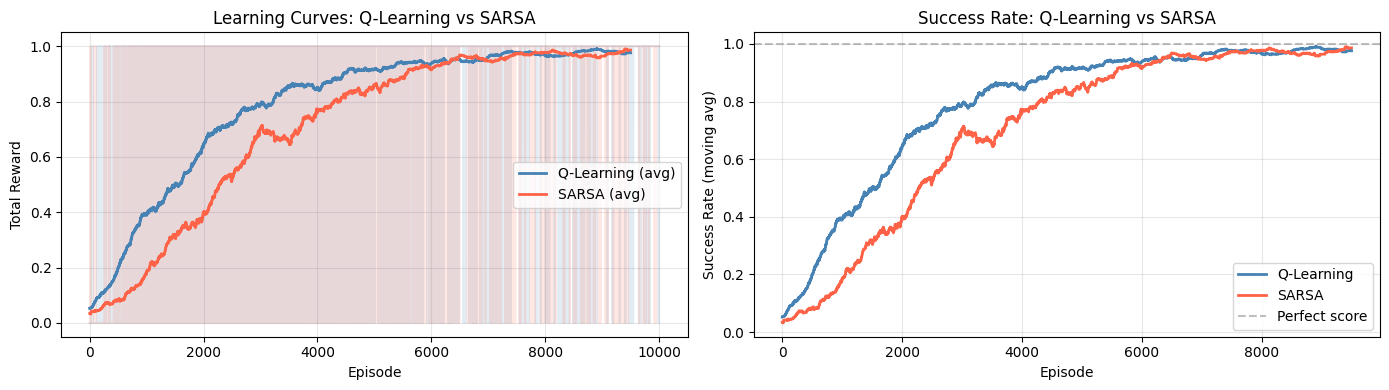

In [6]:
# [T3] Plot learning curves side by side

def moving_average(data, window=500):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Left: raw + smoothed curves for both algorithms ---
ax = axes[0]
ax.plot(rewards_ql,    alpha=0.15, color='steelblue')
ax.plot(rewards_sarsa, alpha=0.15, color='tomato')
ax.plot(moving_average(rewards_ql),    color='steelblue', linewidth=2, label='Q-Learning (avg)')
ax.plot(moving_average(rewards_sarsa), color='tomato',    linewidth=2, label='SARSA (avg)')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Learning Curves: Q-Learning vs SARSA')
ax.legend()
ax.grid(alpha=0.3)

# --- Right: success rate over 500-episode windows ---
ax2 = axes[1]
window = 500
sr_ql    = moving_average(rewards_ql,    window)
sr_sarsa = moving_average(rewards_sarsa, window)
ax2.plot(sr_ql,    color='steelblue', linewidth=2, label='Q-Learning')
ax2.plot(sr_sarsa, color='tomato',    linewidth=2, label='SARSA')
ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Perfect score')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Success Rate (moving avg)')
ax2.set_title('Success Rate: Q-Learning vs SARSA')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sarsa_vs_qlearning.png', dpi=150, bbox_inches='tight')
plt.show()

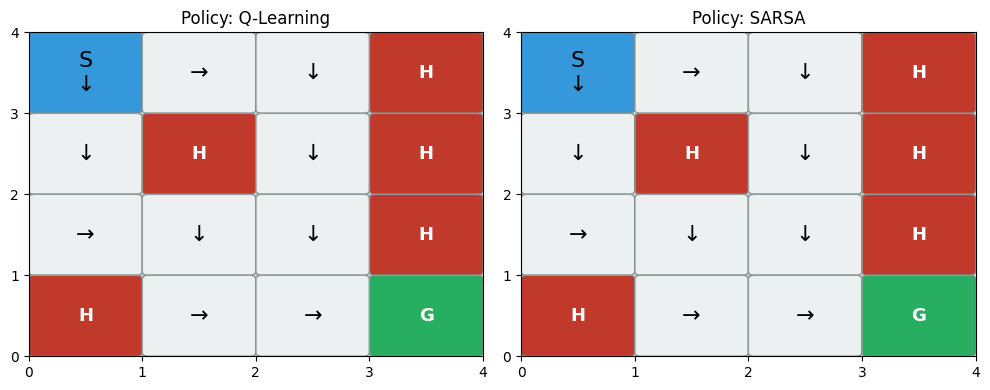

In [7]:
# [T3] Compare learned policies side by side

action_labels = ['←', '↓', '→', '↑']
grid_map = [
    ['S', 'F', 'F', 'H'],
    ['F', 'H', 'F', 'H'],
    ['F', 'F', 'F', 'H'],
    ['H', 'F', 'F', 'G'],
]
holes   = {(0,3),(1,1),(1,3),(2,3),(3,0)}
cell_colors = {'S': '#3498db', 'F': '#ecf0f1', 'H': '#c0392b', 'G': '#27ae60'}

def draw_policy(ax, qtable, title):
    policy = np.argmax(qtable, axis=1)
    ax.set_xlim(0,4); ax.set_ylim(0,4)
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.grid(True, alpha=0.4)
    ax.set_title(title, fontsize=12)
    for r in range(4):
        for c in range(4):
            cell = grid_map[r][c]
            rect = mpatches.FancyBboxPatch(
                (c+0.05, 3-r+0.05), 0.9, 0.9,
                boxstyle='round,pad=0.05',
                linewidth=1, edgecolor='#7f8c8d',
                facecolor=cell_colors[cell]
            )
            ax.add_patch(rect)
            s = r*4 + c
            if cell in ('H', 'G'):
                ax.text(c+0.5, 3-r+0.5, cell, ha='center', va='center',
                        fontsize=13, fontweight='bold', color='white')
            else:
                label = 'S\n' + action_labels[policy[s]] if cell == 'S' else action_labels[policy[s]]
                ax.text(c+0.5, 3-r+0.5, label, ha='center', va='center', fontsize=16)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
draw_policy(axes[0], qtable_ql,    'Policy: Q-Learning')
draw_policy(axes[1], qtable_sarsa, 'Policy: SARSA')
plt.tight_layout()
plt.savefig('sarsa_vs_qlearning_policy.png', dpi=150, bbox_inches='tight')
plt.show()

### T3 Discussion

#### Convergence Speed
Both algorithms converge within a similar number of episodes on the **deterministic (non-slippery)** FrozenLake. Q-Learning may converge slightly faster because it always bootstraps with the best possible Q-value, which propagates optimal values more aggressively through the table.

#### Final Performance
On the non-slippery environment, both algorithms ultimately reach **near-perfect performance** (success rate ≈ 1.0). The environment is simple enough that either algorithm reliably finds the optimal path.

#### Stability
SARSA tends to produce **smoother, more stable** learning curves. Because it updates based on the policy it actually follows (including random exploration), its Q-values are more conservative and less prone to overestimation. Q-Learning can be slightly more noisy early in training because the `max` operator can cause optimistic value estimates.

#### Which Algorithm Performs Better and Why?
- **Non-slippery (deterministic):** Both perform equally well at convergence. Q-Learning may be marginally faster.
- **Slippery (stochastic):** SARSA generally performs **better** because it accounts for exploration risk during updates. Q-Learning overestimates future rewards by assuming optimal actions, which leads to overly risky policies near holes. SARSA's on-policy nature makes it inherently more cautious in stochastic environments — it learns a safer policy that avoids dangerous states even when ε is large.

---
## 🎬 Visualization — Agent Playing the Learned Policy

In [8]:
# Visualize the SARSA agent's learned policy
import matplotlib.animation as animation
from IPython.display import HTML

def visualize_agent(qtable_to_use, title='Agent', is_slippery=False, max_steps=50):
    env_vis = gym.make('FrozenLake-v1', is_slippery=is_slippery)
    state, _ = env_vis.reset()

    trajectory = [state]
    action_names = ['←', '↓', '→', '↑']
    actions_taken = ['🤖']

    for _ in range(max_steps):
        act = np.argmax(qtable_to_use[state, :])
        next_state, reward, terminated, truncated, _ = env_vis.step(act)
        trajectory.append(next_state)
        actions_taken.append(action_names[act])
        state = next_state
        if terminated or truncated:
            break
    env_vis.close()

    grid_map_v = [['S','F','F','H'],['F','H','F','H'],['F','F','F','H'],['H','F','F','G']]
    cell_colors_v = {'S':'#3498db','F':'#ecf0f1','H':'#c0392b','G':'#27ae60'}

    fig, ax = plt.subplots(figsize=(4, 4))

    def draw_frame(t):
        ax.clear()
        ax.set_xlim(0,4); ax.set_ylim(0,4)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect('equal')
        for r in range(4):
            for c in range(4):
                cell = grid_map_v[r][c]
                rect = mpatches.FancyBboxPatch(
                    (c+0.05, 3-r+0.05), 0.9, 0.9,
                    boxstyle='round,pad=0.05',
                    linewidth=1.5, edgecolor='#7f8c8d',
                    facecolor=cell_colors_v[cell]
                )
                ax.add_patch(rect)
                ax.text(c+0.5, 3-r+0.5, cell, ha='center', va='center',
                        fontsize=12, fontweight='bold',
                        color='white' if cell in ('H','S','G') else '#2c3e50')
        ar, ac = trajectory[t] // 4, trajectory[t] % 4
        ax.plot(ac+0.5, 3-ar+0.5, 'o', markersize=28,
                color='#f39c12', markeredgecolor='#d35400', markeredgewidth=2, zorder=5)
        ax.text(ac+0.5, 3-ar+0.5, actions_taken[t],
                ha='center', va='center', fontsize=14, zorder=6)
        result = ''
        if t == len(trajectory)-1:
            result = ' ✅ GOAL!' if grid_map_v[ar][ac]=='G' else ' ❌ HOLE!'
        ax.set_title(f'{title} — Step {t}{result}', fontsize=11)

    ani = animation.FuncAnimation(fig, draw_frame,
                                   frames=len(trajectory),
                                   interval=600, repeat=False)
    plt.tight_layout()
    plt.close()
    return HTML(ani.to_jshtml())

visualize_agent(qtable_sarsa, title='SARSA Agent')

/var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/ipykernel_58430/1968234238.py:61: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  return HTML(ani.to_jshtml())
/var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/ipykernel_58430/1968234238.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  return HTML(ani.to_jshtml())
